In [718]:

import jax.numpy as jnp
from jax import jit, vmap
import math
import numpy as np  # still used for file reading/parsing
from pathlib import Path
from scipy.constants import c, pi
from project_utils import open_pickled_file, setup_matplotlib_styles
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
setup_matplotlib_styles()
colors = ['dodgerblue', 'coral', 'darkviolet', 'limegreen', 'mediumvioletred', 'teal']
sns.set_palette(colors)
from astropy.constants import c, h, L_sun
path_figures = '/Users/amanda/Desktop/PhD/Tools/ceridwen/figs/neb'

(1e-17, 0.1)

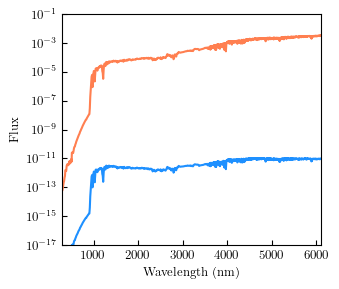

In [359]:
ssp_path = '/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/spectra_young.csv'

spectrum = pd.read_csv(ssp_path)


plt.figure(figsize=(10/3, 3))
for i, col in enumerate(spectrum.columns[1:]):
    plt.plot(spectrum['wave'], spectrum[col], label=col, lw=1.5)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux')
plt.xlim(300, 6100)
plt.yscale('log')
plt.ylim(1e-17, 1e-1)

In [1046]:
class NebularModel:
    def __init__(self, isoc_type, cloudy_dust, sps_home, csp_lambda,
                mypi, smooth_velocity=True, nebnz=11, nebnage=10, nebnip=7, nebular_smooth_init=100.0):
        self.csp_lambda = jnp.asarray(csp_lambda)
        self.nspec = self.csp_lambda.size
        self.mypi = mypi
        self.smooth_velocity = smooth_velocity
        self.nebular_smooth_init = nebular_smooth_init
        self.nebnz = nebnz
        self.nebnage = nebnage
        self.nebnip = nebnip

        # File paths
        suffix = 'WD' if cloudy_dust else 'ND'
        base = Path(sps_home) / 'nebular' / f'ZAU_{suffix}_{isoc_type}'
        self.cont_file = base.with_suffix('.cont')
        self.line_file = base.with_suffix('.lines')

        # Load data
        self._load_continuum()
        self._load_lines()
        self._compute_resolution_elements()
        self._build_gaussians()

    def _load_continuum(self): 
        with open(self.cont_file, 'r') as f:
            f.readline()
            readlambneb = np.array([float(x) for x in f.readline().split()])
            nlam = len(readlambneb)
            self.readlambneb = jnp.asarray(readlambneb)

            lines = f.readlines()
            cont_cube = np.zeros((self.nspec, self.nebnz, self.nebnage, self.nebnip))
            logz_grid = np.zeros(self.nebnz)
            logu_grid = np.zeros(self.nebnip)
            age_grid = np.zeros(self.nebnage)


            idx = 0
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        parts = [float(x) for x in lines[idx].split()]
                        logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                        idx += 1
                        cont = np.array([float(x) for x in lines[idx].split()]) #Units are Lsun/Hz/Q
                        logcont = np.log10(cont + 10**-95)
                        cont_interp = jnp.interp(self.csp_lambda, readlambneb, logcont)
                        cont_cube[:, i, j, k] = cont_interp
                        idx += 1

            self.nebem_cont = jnp.asarray(cont_cube)
            self.nebem_logz = jnp.asarray(logz_grid)
            self.nebem_logu = jnp.asarray(logu_grid)
            self.nebem_age = jnp.log10(jnp.asarray(age_grid))

    def _load_lines(self):
        with open(self.line_file, 'r') as f:
            f.readline()
            self.nebem_line_pos = jnp.array([float(x) for x in f.readline().split()])
            self.nemline = self.nebem_line_pos.shape[0]
            line_cube = np.zeros((self.nemline, self.nebnz, self.nebnage, self.nebnip))

            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        f.readline()
                        linevals = np.array([float(x) for x in f.readline().split()])
                        line_cube[:, i, j, k] = np.log10(linevals + 10**-95)

            self.nebem_line = jnp.asarray(line_cube)

    def _compute_resolution_elements(self):
        idx = jnp.clip(jnp.searchsorted(self.csp_lambda, self.nebem_line_pos) - 1, 1, self.nspec - 2)
        dlam = self.csp_lambda[idx + 1] - self.csp_lambda[idx]
        self.neb_res_min = jnp.asarray(dlam) #jnp.full_like(dlam, 1) #
        

    def _build_gaussians(self):
        # Broadcast wavelength grid and line centers for vectorized operations
        csp_lambda_exp = self.csp_lambda[:, None]  # shape (N_lambda, 1)
        nebem_line_pos_exp = self.nebem_line_pos[None, :]  # shape (1, nemline)
        
        if self.smooth_velocity:# smoothing variable is km/s
            dlam = self.nebem_line_pos * self.nebular_smooth_init / (c * 1e13)
        else: # smoothing variable is in Angstrom
            dlam = jnp.full_like(self.nebem_line_pos, self.nebular_smooth_init)
        
        # Clamp dlam
        dlam = self.neb_res_min / 2.355 # jnp.maximum(dlam, self.neb_res_min * 2)  # shape (nemline,)
        self.dlam = dlam  # Store for later use if needed
        # Expand dlam for broadcasting
        
        dlam_exp = dlam[None, :]  # shape (1, nemline) for broadcasting
        
        # Calculate Gaussian profiles for all lines at once
        prof = jnp.exp(-((csp_lambda_exp - nebem_line_pos_exp)**2) / 2 / dlam_exp**2)/(jnp.sqrt(2 * self.mypi) * dlam_exp)
        
        # Normalize profiles: flux conservation in velocity space
        # norm_factor = jnp.sqrt(2 * self.mypi) * dlam_exp * c * nebem_line_pos_exp**2  # shape (1, nemline)
        # prof /= norm_factor

        prof = prof * csp_lambda_exp**2 / (c * 1e10)  # Convert to erg/s/cm²/Å
        
        self.gaussnebarr = prof  # shape (N_lambda, nemline)


    def evaluate(self, logZ, logU, logage, Q):

        # Locate and compute fractional offsets in grid
        z1 = locate(logZ, self.nebem_logz)
        dz = jnp.clip((logZ - self.nebem_logz[z1]) / (self.nebem_logz[z1 + 1] - self.nebem_logz[z1]), 0.0, 1.0)

        u1 = locate(logU, self.nebem_logu)
        du = jnp.clip((logU - self.nebem_logu[u1]) / (self.nebem_logu[u1 + 1] - self.nebem_logu[u1]), 0.0, 1.0)

        a1 = locate(logage, self.nebem_age)
        da = jnp.clip((logage - self.nebem_age[a1]) / (self.nebem_age[a1 + 1] - self.nebem_age[a1]), 0.0, 1.0)

        # Compute log10(Q), ensuring correct dtype
        logQ = math.log10(Q)
        
        # Interpolate log-continuum and line luminosity
        logcont_interp = trilinear_interp(self.nebem_cont, z1, dz, a1, da, u1, du)
        loglines_interp = trilinear_interp(self.nebem_line, z1, dz, a1, da, u1, du)

        # Combine with logQ
        log_cont_flux = logcont_interp + logQ
        log_line_flux = loglines_interp + logQ
        
        # Convert to linear only where absolutely necessary
        cont_flux = 10 ** log_cont_flux  # shape (nspec,)
        line_flux = 10 ** log_line_flux  # shape (nlines,)
        
        # Combine lines
        line_spec = jnp.dot(self.gaussnebarr, line_flux)   # shape (nspec,)
        self.linespec = line_spec  # Store for later use if needed
        self.conflux = cont_flux  # Store for later use if needed
        self.lineflux = line_flux  # Store for later use if needed

        # Final SED
        spec = cont_flux + line_spec  # both in erg/s/cm²/Å

        return spec

    def get_neb_spec(self, logZ, logU, logage, spectrum, wavelength, frac_obrun=0.0):
        """
        Get the nebular spectrum for given metallicity, ionization parameter, age, and ionizing photon rate.

        Parameters
        ----------
        logZ : float
            Logarithmic metallicity (Z/Zsun)
        logU : float
            Logarithmic ionization parameter (dimensionless)
        logage : float
            Logarithmic age of the stellar population (years)
        Q : float
            Ionizing photon production rate (photons/s)

        Returns
        -------
        spec : array (nspec,)
            Nebular spectrum in erg/s/cm²/Å
        """
        Q = compute_ionizing_photon_rate_solar_units(spectrum, wavelength, frac_obrun, hplank=6.62607015e-27, clight=c )
        print('we found the Q', Q)
        return self.evaluate(logZ, logU, logage, Q)
    
def locate(x, grid):
    return jnp.clip(jnp.searchsorted(grid, x) - 1, 0, grid.size - 2)

def trilinear_interp(cube, z1, dz, a1, da, u1, du):
    """
    Trilinear interpolation on a 4D cube: shape (nspec, nz, nage, nu)
    """
    # Interpolation weights for the 8 surrounding points
    w = jnp.array([
        (1 - dz) * (1 - da) * (1 - du),
        (1 - dz) * (1 - da) * du,
        (1 - dz) * da * (1 - du),
        (1 - dz) * da * du,
        dz * (1 - da) * (1 - du),
        dz * (1 - da) * du,
        dz * da * (1 - du),
        dz * da * du
    ])

    # Stack the 8 corners along a new axis (0), each of shape (nspec,)
    slices = jnp.stack([
        cube[:, z1,   a1,   u1],
        cube[:, z1,   a1,   u1+1],
        cube[:, z1,   a1+1, u1],
        cube[:, z1,   a1+1, u1+1],
        cube[:, z1+1, a1,   u1],
        cube[:, z1+1, a1,   u1+1],
        cube[:, z1+1, a1+1, u1],
        cube[:, z1+1, a1+1, u1+1]
    ], axis=0)  # shape (8, nspec)

    # Weighted sum over the 8 corners
    return jnp.sum(w[:, None] * slices, axis=0)  # shape (nspec,)

def compute_ionizing_photon_rate_solar_units(spectrum, wavelengths, frac_obrun, hplank, clight):
    """
    Compute the ionizing photon production rate Q from a stellar spectrum in units of L_sun / Hz.

    Parameters
    ----------
    spectrum : array (nspec,)
        Stellar spectrum in L_sun / Hz
    wavelengths : array (nspec,)
        Wavelength array in Angstrom
    frac_obrun : float
        Fraction of OB stars that are runaways (not embedded in HII regions)
    hplank : float
        Planck constant in erg*s
    clight : float
        Speed of light in cm/s

    Returns
    -------
    Q : float
        Ionizing photon production rate (photons/s)
    """
    spectrum = jnp.asarray(spectrum)
    wavelengths = jnp.asarray(wavelengths)
    spec_nu = clight / (wavelengths * 1e-8)  # Å → cm

    whlylim = jnp.sum(wavelengths < 912.0)

    sspi_ion = spectrum[:whlylim]
    integrand = sspi_ion / spec_nu[:whlylim]

    # Result is in photons/s, since L_sun cancels out in numerator and denominator
    Q = jnp.trapezoid(integrand, spec_nu[:whlylim]) / hplank

    return - Q * jnp.clip(1.0 - frac_obrun, 0.0, 1.0)

In [1047]:
model.dlam

Array([2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01,
       2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01,
       2.00e+01, 2.00e+01, 2.00e+01, 1.40e+01, 2.00e+01, 2.00e+01,
       2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01,
       2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01,
       2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 4.00e+01, 4.00e+01,
       4.00e+01, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00,
       2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00,
       2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00,
       2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00,
       2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00,
       2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00,
       2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00,
       2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00,
       2.00e+00, 2.00e+00, 2.00e+00, 4.00e+01, 4.00e+01, 4.00e

(300.0, 6100.0)

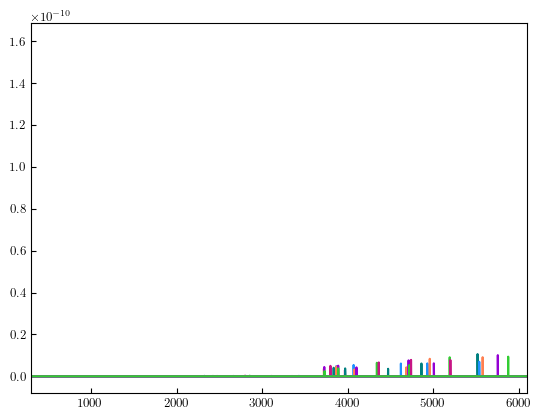

In [1048]:
model = NebularModel(
    isoc_type="mist",
    cloudy_dust=True,
    sps_home="/Users/amanda/Prospector/fsps",
    csp_lambda=spectrum['wave'],
    mypi=np.pi,
    nebular_smooth_init=2,
    smooth_velocity=False
)
spec = model.evaluate(
    logZ=-0.82,  # Example metallicity
    logU=-2.0,  # Example ionization parameter
    logage=7.10037,  # Example age in log years
    Q=6.539193928799016e+47  # Example ionizing photon rate
)

plt.plot(model.csp_lambda, model.gaussnebarr, label='Nebular Spectrum', lw=1.5)

plt.xlim(300, 6100)

In [1037]:

import fsps 
sp = fsps.StellarPopulation(zcontinuous=1, sfh=0,
                                add_neb_emission=1)

fsps_spectrum = sp.get_spectrum()

In [1034]:
fsps_spectrum


(array([9.100e+01, 9.400e+01, 9.600e+01, ..., 9.817e+07, 9.908e+07,
        1.000e+08], shape=(5994,)),
 array([[9.25442116e-40, 4.58514503e-40, 2.81319279e-40, ...,
         1.22557274e-13, 1.22699068e-13, 1.22840862e-13],
        [9.05892342e-40, 4.48828479e-40, 2.75376467e-40, ...,
         1.19968277e-13, 1.20107076e-13, 1.20245874e-13],
        [9.21672642e-40, 4.56646900e-40, 2.80173420e-40, ...,
         1.22058079e-13, 1.22199295e-13, 1.22340511e-13],
        ...,
        [2.37386986e-25, 3.41214491e-25, 4.70297514e-25, ...,
         5.64295315e-23, 5.53946362e-23, 5.43779874e-23],
        [1.16701016e-25, 1.75447461e-25, 2.45072470e-25, ...,
         4.94217721e-23, 4.85155815e-23, 4.76251466e-23],
        [6.16843811e-26, 1.00613755e-25, 1.43985004e-25, ...,
         4.87019632e-23, 4.78090377e-23, 4.69317847e-23]],
       shape=(107, 5994)))

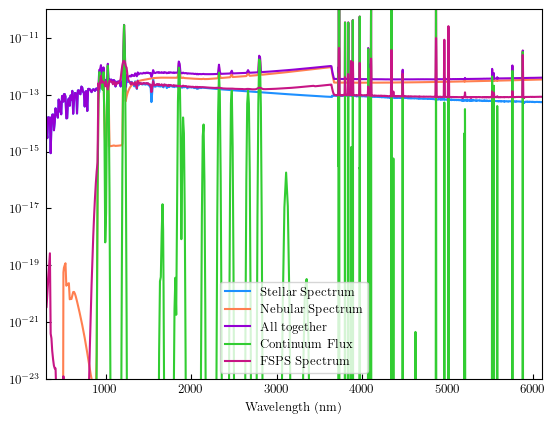

In [1049]:
plt.plot(spectrum['wave'], speci, label='Stellar Spectrum', lw=1.5)
plt.plot(model.csp_lambda, spec, label='Nebular Spectrum', lw=1.5)
plt.plot(model.csp_lambda, spec +speci, label='All together', lw=1.5)
plt.plot(model.csp_lambda, model.linespec, label='Continuum Flux', lw=1.5)
plt.plot(model.csp_lambda, fsps_spectrum[1][1, :], label='FSPS Spectrum', lw=1.5)
#plt.plot(model.csp_lambda, model.linespec, label='Nebular Lines', lw=1.5)
plt.xlabel('Wavelength (nm)')
plt.yscale('log')
plt.xlim(300, 6100)
plt.ylim(1e-23, 1e-10)
plt.legend()

In [913]:
10**(ssp_data.ssp_lg_age_gyr)

Array([1.0000000e-06, 9.9999997e-05, 1.1220184e-04, 1.2589252e-04,
       1.4125378e-04, 1.5848933e-04, 1.7782794e-04, 1.9952621e-04,
       2.2387206e-04, 2.5118870e-04, 2.8183832e-04, 3.1622776e-04,
       3.5481335e-04, 3.9810708e-04, 4.4668370e-04, 5.0118729e-04,
       5.6234130e-04, 6.3095725e-04, 7.0794561e-04, 7.9432840e-04,
       8.9125102e-04, 1.0000000e-03, 1.1220183e-03, 1.2589252e-03,
       1.4125379e-03, 1.5848933e-03, 1.7782794e-03, 1.9952620e-03,
       2.2387207e-03, 2.5118869e-03, 2.8183833e-03, 3.1622776e-03,
       3.5481334e-03, 3.9810711e-03, 4.4668368e-03, 5.0118729e-03,
       5.6234132e-03, 6.3095726e-03, 7.0794565e-03, 7.9432838e-03,
       8.9125102e-03, 9.9999998e-03, 1.1220183e-02, 1.2589254e-02,
       1.4125375e-02, 1.5848933e-02, 1.7782794e-02, 1.9952621e-02,
       2.2387212e-02, 2.5118863e-02, 2.8183833e-02, 3.1622775e-02,
       3.5481334e-02, 3.9810721e-02, 4.4668358e-02, 5.0118729e-02,
       5.6234132e-02, 6.3095726e-02, 7.0794582e-02, 7.9432823e

In [891]:
# Add the root project directory to the system path
import sys
sys.path.append(os.path.abspath(".."))
from ssps.ssp_data import SSPData
filename = '/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5'
ssp_data = SSPData.load(filename)

In [914]:
locate(7*1e-3, 10**(ssp_data.ssp_lg_age_gyr))

Array(37, dtype=int32)

In [896]:
locate(-0.82, ssp_data.ssp_lgmet)

Array(10, dtype=int32)

In [984]:
def get_qq(spectrum, wavelengths, frac_obrun):
    """
    Compute the ionizing photon production rate Q from a stellar spectrum.

    Parameters
    ----------
    spectrum : array-like
        Stellar spectrum in units of L_sun / Hz (i.e., solar luminosity per unit frequency)
    wavelengths : array-like
        Wavelength array in Angstrom
    frac_obrun : float
        Fraction of OB stars that are runaways (not embedded in HII regions)

    Returns
    -------
    qq : float
        Ionizing photon production rate in photons/s
    """
    # Mask for ionizing photons: λ < 911.6 Å (Lyman limit)
    mask = wavelengths < 911.6

    spec_nu = c / (wavelengths * 1e-10)
    spec_nu = spec_nu[mask]

    #spec_ion = spectrum[mask] / spec_nu * wavelengths[mask]
    spec_ion = spectrum[mask] * wavelengths[mask]**2 / (c*1e10)

    qq = -jnp.trapezoid(spec_ion, spec_nu)  

    # Correct for OB star runaway fraction: these stars do not contribute ionizing photons
    qq *= (1.0 - frac_obrun)

    # Convert unitless Q (in L_sun / h) to physical units: photons/s
    # Multiply by L_sun / h and take log10 for numerical stability
    return 10 ** (math.log10(qq) - math.log10(h.value) + math.log10(L_sun.value))


speci = ssp_data.ssp_flux[100, 0, :]

qq = get_qq(speci, ssp_data.ssp_wave, 0.0)
qq

2.836538967180587e+49

In [981]:
ssp_data.ssp_lgmet

Array([-4.3477116, -3.8477113, -3.5977116, -3.3477113, -3.0977116,
       -2.8477116, -2.5977116, -2.3477116, -2.0977116, -1.8477116,
       -1.5977116, -1.3477116], dtype=float32)

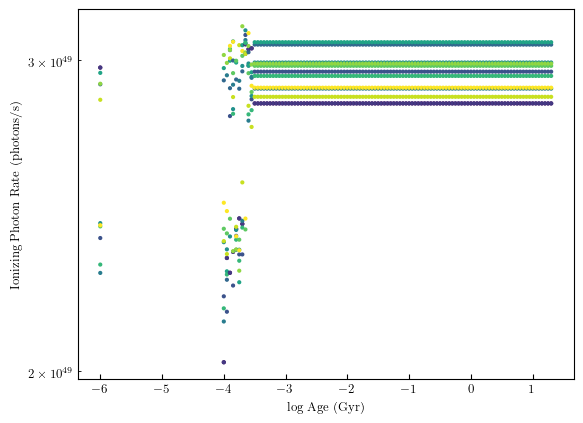

In [982]:
qq = []
age = []
met = []

for a in range(len(ssp_data.ssp_lg_age_gyr)):
    for m in range(len(ssp_data.ssp_lgmet)):
        q = get_qq(ssp_data.ssp_flux[a, m, :], ssp_data.ssp_wave, 0.0)
        qq.append(q)
        age.append(ssp_data.ssp_lg_age_gyr[a])
        met.append(ssp_data.ssp_lgmet[m])

# Convert to arrays
age = np.array(age)
qq = np.array(qq)
met = np.array(met)

# Normalize metallicity to [0, 1] range for colormap
met_norm = (met - met.min()) / (met.max() - met.min())

# Map normalized metallicity to colors
cmap = sns.color_palette("viridis", as_cmap=True)
colors = cmap(met_norm)

# Plot
plt.figure()
plt.scatter(age, qq, c=colors, s=4)
plt.xlabel('log Age (Gyr)')
plt.ylabel('Ionizing Photon Rate (photons/s)')
plt.yscale('log')


(0.0, 3000.0)

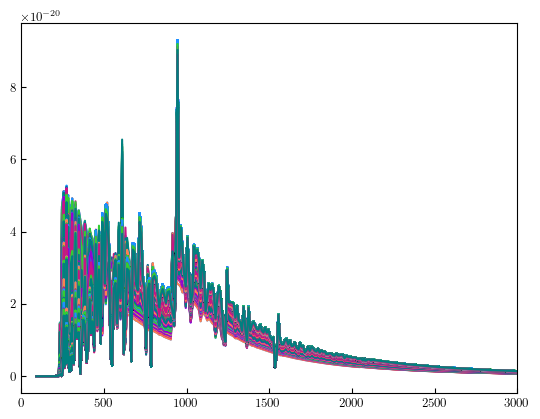

In [1010]:
for a in range(len(ssp_data.ssp_lg_age_gyr)):
    for m in range(len(ssp_data.ssp_lgmet)):
        plt.plot(ssp_data.ssp_wave, fnu2flam(ssp_data.ssp_wave, ssp_data.ssp_flux[a, m, :]*3631*10**-23))

plt.xlim(0, 3000)



In [991]:
ssp_data.ssp_flux.size/5884

1320.2284160435079

In [997]:
def fnu2flam(lam,fnu): # fnu in erg/s/cm2/Hz
            c = 2.998e18 #A/s
            flam = c* fnu / lam**2
            return flam

(0.0, 5000.0)

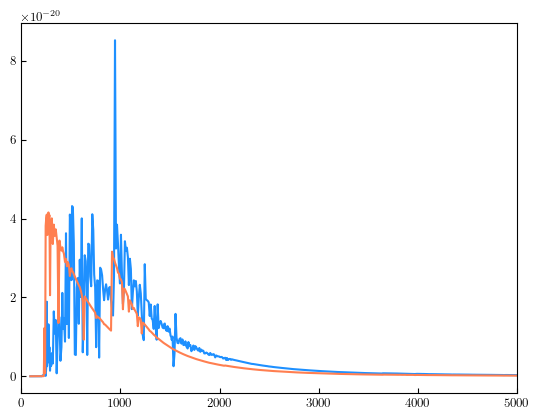

In [1001]:
speci = ssp_data.ssp_flux[107, 0, :]

plt.plot( ssp_data.ssp_wave, fnu2flam(ssp_data.ssp_wave, speci*3631*10**-23))
speci2 = ssp_data.ssp_flux[0, 11, :]

plt.plot( ssp_data.ssp_wave, fnu2flam(ssp_data.ssp_wave, speci2*3631*10**-23))
plt.xlim(0, 5000)

In [884]:
def get_qq(spectrum, wavelengths, frac_obrun):
    """
    Compute the ionizing photon production rate Q from a stellar spectrum.

    Parameters
    ----------
    spectrum : array-like
        Stellar spectrum in units of L_sun / Hz (i.e., solar luminosity per unit frequency)
    wavelengths : array-like
        Wavelength array in Angstrom
    frac_obrun : float
        Fraction of OB stars that are runaways (not embedded in HII regions)

    Returns
    -------
    qq : float
        Ionizing photon production rate in photons/s
    """
    # Mask for ionizing photons: λ < 911.6 Å (Lyman limit)
    mask = wavelengths < 911.6

    spec_nu = c / (wavelengths * 1e-10)
    spec_nu = spec_nu[mask]

    #spec_ion = spectrum[mask] / spec_nu * wavelengths[mask]
    spec_ion = spectrum[mask] * wavelengths[mask]**2 / (c*1e10)

    qq = -jnp.trapezoid(spec_ion, spec_nu)  

    # Correct for OB star runaway fraction: these stars do not contribute ionizing photons
    qq *= (1.0 - frac_obrun)

    # Convert unitless Q (in L_sun / h) to physical units: photons/s
    # Multiply by L_sun / h and take log10 for numerical stability
    return 10 ** (math.log10(qq) - math.log10(h.value) + math.log10(L_sun.value))

In [885]:
q = get_qq(jnp.array(spectrum['flux']), jnp.array(spectrum['wave']), frac_obrun=0.0)

In [886]:
q

8.684199615299244e+46

(0.0, 1000.0)

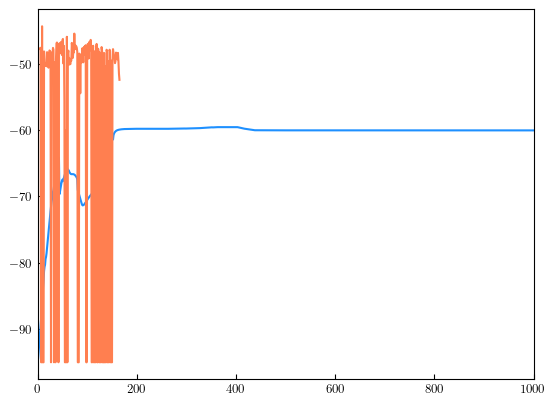

In [833]:
plt.plot(model.nebem_cont[:, 0, 0, 0], label='Continuum')
plt.plot(model.nebem_line[:, 0, 0, 0], label='Lines')
plt.xlim(0, 1000)

(300.0, 6100.0)

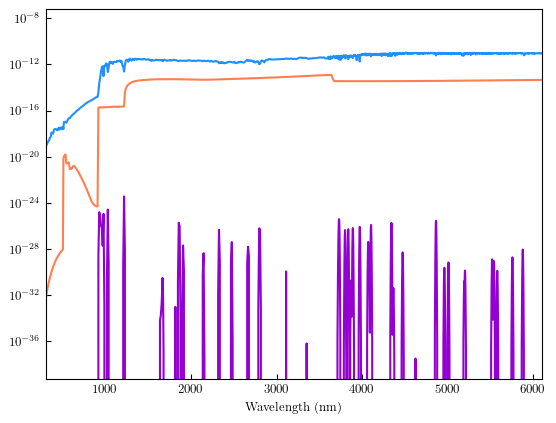

In [834]:
plt.plot(spectrum['wave'], spectrum['flux'], label='Stellar Spectrum', lw=1.5)
plt.plot(model.csp_lambda, spec, label='Nebular Spectrum', lw=1.5)
plt.plot(model.csp_lambda, model.linespec, label='Nebular Lines', lw=1.5)
plt.xlabel('Wavelength (nm)')
plt.yscale('log')
plt.xlim(300, 6100)

(300.0, 6100.0)

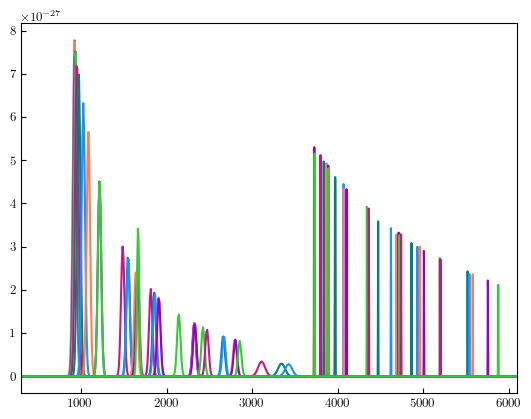

In [783]:
c

<<class 'astropy.constants.codata2018.CODATA2018'> name='Speed of light in vacuum' value=299792458.0 uncertainty=0.0 unit='m / s' reference='CODATA 2018'>

In [687]:
model.nebem_line[:0, 0, 0]

Array([], shape=(0, 7), dtype=float32)

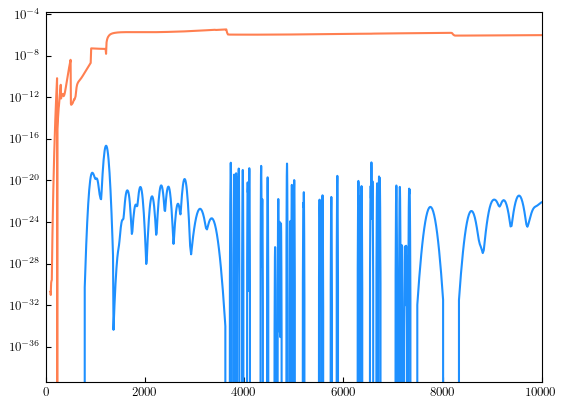

In [684]:
plt.plot(model.csp_lambda, jnp.dot(model.gaussnebarr, 10**(model.nebem_line[:,0, 0, 0] + logQ)))
plt.plot(model.csp_lambda, 10**(model.nebem_cont[:, 0, 0, 0] + logQ))
plt.xlim(0, 10000)
plt.yscale('log')

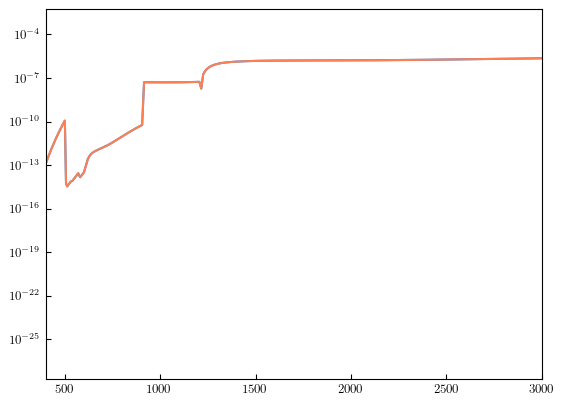

In [635]:
plt.plot(model.csp_lambda, full)
plt.plot(model.csp_lambda, model.conflux)
plt.xlim(400, 3000)
plt.yscale('log')

(400.0, 3000.0)

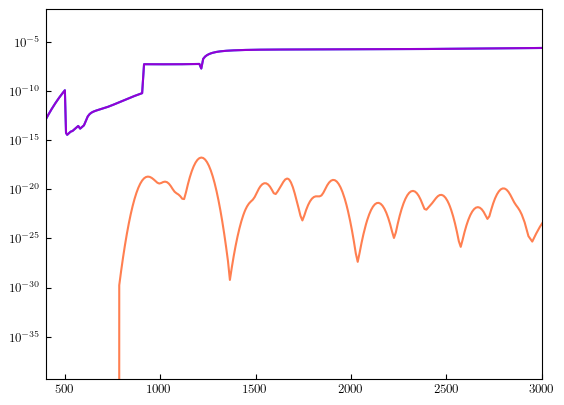

In [631]:
plt.plot(model.csp_lambda, model.conflux)
plt.plot(model.csp_lambda, model.linespec)
plt.plot(model.csp_lambda, spec, label='Total Spectrum', lw=1.5)
plt.yscale('log')
plt.xlim(400, 3000)


In [ ]:
def return_Nion(lam, spec):
    '''
    returns ionizing luminosity (<912 \AA) in erg/s
    input spectrum must be Lsun/Hz, wavelength in \AA
    '''
    lsun = 3.839e+33 #by searching charlie's github, this is in ergs/second
    hplank = 6.6261e-27 #by searching charlie's github
    c = 2.998e+18 #in angstroms/sec because we are converting wavelength in angstroms to these units
    nu = c/lam #frequency

    mask = (lam<911.6) & (spec>0.0)  # mask for wavelengths < 912 Å and positive flux

    nion = -jnp.trapezoid((spec/nu)[mask], x=nu[mask])
    l_uv = np.mean(spec[(lam>1450) & (lam<1550)])*lsun
    return nion, l_uv

q, luv = return_Nion(
    jnp.asarray(spectrum['wave']),  # Use the wave column from the spectrum DataFrame
    jnp.asarray(spectrum['flux'])  # Use the flux_fnu column from the spectrum DataFrame
)
print(q)

mask [False False False ... False False False]
1.8423446e-16


In [757]:
from astropy.constants import c, h, L_sun

def get_qq(spectrum, wavelengths, frac_obrun):

    mask = wavelengths < 911.6
    spec_nu = c / (wavelengths * 1e-10) [mask] # Convert wavelengths from Angstrom to cm
    spec_ion = spectrum[mask] / spec_nu  # L_sun / Hz to photons/s
    qq = -jnp.trapezoid(spec_ion, spec_nu) 
    qq *= (1.0 - frac_obrun)  # Adjust for runaway stars
    return 10**(math.log10(qq / h.value) + math.log10(L_sun.value)) # Convert to photons/s in solar units
    
q = get_qq(
    jnp.asarray(spectrum['flux']),  # Use the flux column from the spectrum DataFrame
    jnp.asarray(spectrum['wave']),  # Use the wave column from the spectrum DataFrame
    frac_obrun=0.0  # No OB runaway stars for this example
)
   # Convert to log10(photons/s) in solar units

q


1.0643556629444693e+44

In [748]:
np.array(range(1, 67))

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66])

In [ ]:
def get_q(spectrum, wavelengths, frac_obrun):
    spout = jnp.asarray(spectrum)
    
    ionidx = locate(913, wavelengths) +1
    spout = spout.at[:ionidx].set(spectrum[:ionidx] * max(min(frac_obrun, 1.0), 0.0))

    spec_nu = c/ wavelengths  # Convert wavelengths from Angstrom to cm
    qq = -jnp.trapezoid( spectrum[:ionidx]/spec_nu[:ionidx], spec_nu[:ionidx]) 
    qq = qq*(1.0 - frac_obrun)  # Adjust for runaway stars
    return qq


get_q(
    jnp.asarray(spectrum['flux']),  # Use the flux column from the spectrum DataFrame
    jnp.asarray(spectrum['wave']),  # Use the wave column from the spectrum DataFrame
    frac_obrun=0.0,  # No OB runaway stars for this example
)

ionidx 122


Array(1.8423447e-16, dtype=float32)

In [696]:
c

2.998e+18

In [692]:
mask = (spectrum['wave'] < 911.6)
spec_nu = 2.998e+8 / (spectrum['wave'] * 1e-10)  # Convert wavelengths from Angstrom to cm
spec_nu

0       3.294505e+16
1       3.189362e+16
2       3.122917e+16
3       3.059184e+16
4       2.998000e+16
            ...     
5989    3.110604e+10
5990    3.082142e+10
5991    3.053886e+10
5992    3.025838e+10
5993    2.998000e+10
Name: wave, Length: 5994, dtype: float64

In [693]:
q, luv = return_Nion(
    jnp.asarray(spectrum['wave']),  # Use the wave column from the spectrum DataFrame
    jnp.asarray(spectrum['flux'])  # Use the flux_fnu column from the spectrum DataFrame
)
print(q)
math.log10(q) + math.log10(lsun/hplank)
10**(math.log10(q) + math.log10(lsun/hplank))  # Convert to photons/s


mask [False False False ... False False False]
1.8423446e-16


1.0674093065986916e+44

In [517]:
jnp.log10(q) - jnp.log10(hplank)

10**(jnp.log10(q) - jnp.log10(hplank))  # Convert to photons/s

Array(2.7804353e+10, dtype=float32)

In [510]:
tes = (q*lsun)
tes/hplank

Array(inf, dtype=float32)

In [531]:
lsun = 3.839e+33 #by searching charlie's github, this is in ergs/second
hplank = 6.6261e-27 #by searching charlie's github
c = 2.998e+18 #in angstroms/sec because we are converting wavelength in angstroms to these units
nu = c/jnp.array(spectrum['wave']) #frequency

mask = (jnp.array(spectrum['wave'])<911.6)
msked_spectrum = jnp.array(spectrum['flux'])[mask]
msked_nu = nu[mask]
pre = -jnp.trapezoid(msked_spectrum/msked_nu, x=msked_nu) * lsun  # Integral of flux density over frequency

q = 10**(math.log10(pre) - math.log10(hplank))  # Convert to photons/s
print('Ionizing photon rate Q:', q)

Ionizing photon rate Q: 1.067409351339009e+44


In [490]:
arflux = np.array(spectrum['flux_fnu'])

In [ ]:
all = jnp.log10(arflux/nu*lsun) - jnp.log10(hplank)

Array([ 0.,  0.,  0., ..., inf, inf, inf], dtype=float32)

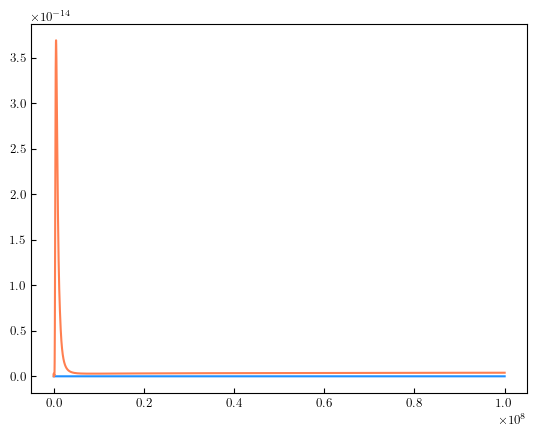

In [506]:
plt.plot(model.csp_lambda, model.linespec)
plt.plot(model.csp_lambda, spec, label='Nebular SED', lw=1.5)


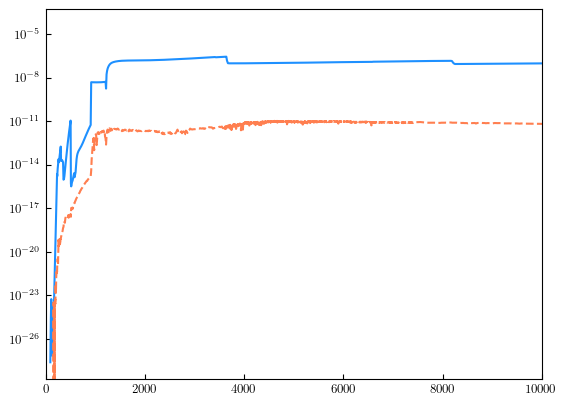

In [440]:
plt.plot(model.csp_lambda, spec)
plt.plot(spectrum['wave'], spectrum['flux'], label='SSP', lw=1.5, ls='--')
plt.xlim(0, 10000)
plt.yscale('log')

In [117]:
def convert_logspace_nebular_flux(
    logcont_interp, wave_angstrom, Q, D_L_cm
):
    logLsun = np.log10(3.828e33)
    logc = np.log10(2.99792458e10)
    log4pi = np.log10(4 * np.pi)

    log_fnu = logcont_interp + logLsun
    log_lambda = np.log10(wave_angstrom) - 8  # convert Å to cm in log
    log_flam = log_fnu + logc - 2 * log_lambda - 8  # extra -8 for /Å

    log_Flambda = log_flam + np.log10(Q) - 2 * np.log10(D_L_cm) - log4pi
    F_lambda = 10**log_Flambda
    return F_lambda

F_lambda = convert_logspace_nebular_flux(
    logcont_interp=model.nebem_cont[:, 0, 0, -3],  # Example: first metallicity, age, and ionization parameter
    wave_angstrom=model.csp_lambda,
    Q=1e53,                        # example value
    D_L_cm=3.086e27                # ~10 Gpc
)

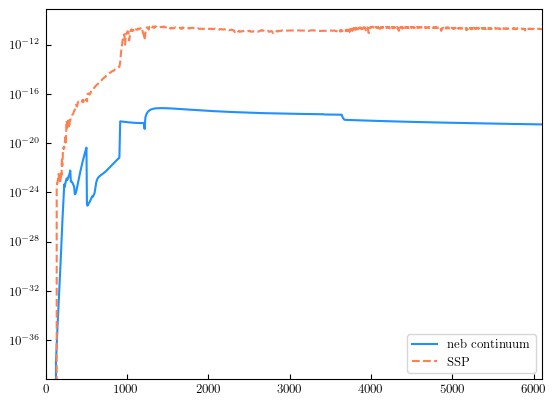

In [118]:
plt.plot(model.csp_lambda, F_lambda, lw=1.5, label='neb continuum')
plt.plot(spectrum['wave'], spectrum['flux'], label='SSP', lw=1.5, ls='--')
plt.xlim(0, 6100)
plt.yscale('log')
plt.legend()

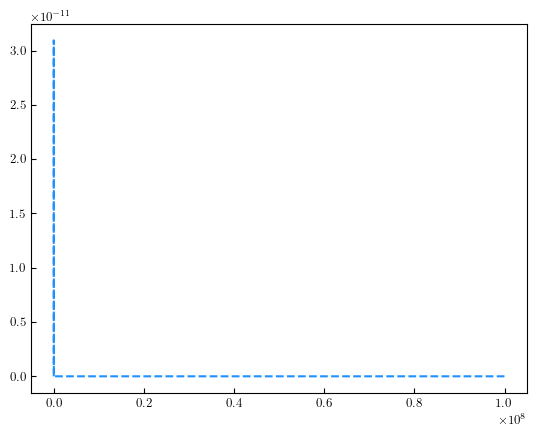

In [43]:
import h5py

with h5py.File("nebular_continuum_grid.h5", "w") as f:
    f.create_dataset("neb_cont", data=model.nebem_cont)
    f.create_dataset("wavelength", data=model.csp_lambda)           # shape (5994,)
    f.create_dataset("logZ", data=model.nebem_logz)                 # shape (11,)
    f.create_dataset("logAge", data=model.nebem_age)             # shape (10,)
    f.create_dataset("logU", data=model.nebem_logu)                 # shape (7,)

In [27]:
def fnu2flam(lam,fnu): # fnu in erg/s/cm2/Hz
    c = 2.998e18 #A/s
    flam = c* fnu / lam**2
    return flam

In [48]:
model.nebem_cont[:, 0, 0, 0]*3.846e33

Array([-3.2585735e+35, -3.2593658e+35, -3.2599448e+35, ...,
       -2.2881719e+35, -2.2881458e+35, -2.2881301e+35], dtype=float32)

(0.0, 2000.0)

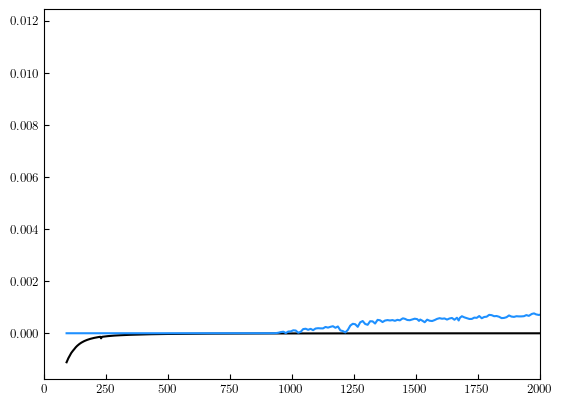

In [33]:
neb = fnu2flam(spectrum['wave'], model.nebem_cont[:, 0, 0, 0]*3631*10**-23)
plt.plot(spectrum['wave'], neb, label='Nebular Continuum', lw=1.5, color='black')
plt.plot(spectrum['wave'], spectrum['flux_fnu'])
plt.xlim(0, 2000)

Text(0, 0.5, 'Flux')

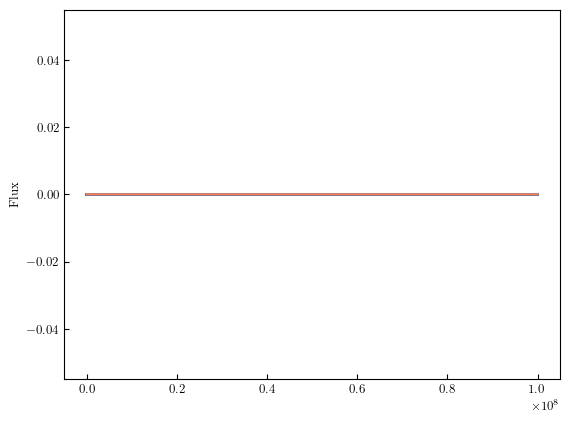

In [53]:
for i in range(11):
    for j in range(10):
            plt.plot(model.csp_lambda, 10**(model.nebem_cont[:, i, j, 0])*3.846e33 *1e6)

plt.ylabel('Flux')

#plt.plot(spectrum['wave'], jnp.log10(jnp.array(spectrum['flux_fnu'])))

#plt.ylim(1e-17, 1e-1)

In [8]:
def locate(x, grid):
    return jnp.clip(jnp.searchsorted(grid, x) - 1, 0, grid.size - 2)

locate(0.0, jnp.array([-1.3 , -1.  , -0.82, -0.7 , -0.52, -0.4 , -0.3 , -0.15,  0.  ,
        0.18,  0.3 ]))

Array(7, dtype=int32)

In [5]:
model = NebularModel(
    isoc_type="bpss",
    cloudy_dust=True,
    sps_home="/Users/amanda/Prospector/fsps",
    csp_lambda=spectrum['wave'],
    clight=c * 1e10,
    mypi=np.pi,
    nebular_smooth_init=100.0
)
model.evaluate(
    logZ=0.0,  # Example metallicity
    logU=-2.0,  # Example ionization parameter
    logage=7.0,  # Example age in log years
    Q=1e53  # Example ionizing photon rate
)

z1: 7, dz: 1.0, a1: 6, da: 4.7507742237939965e-06, u1: 3, du: 1.0


/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_8739/835498650.py:132: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  logQ = jnp.log(jnp.asarray(Q, dtype=jnp.float64)) / jnp.log(10.)
/Users/amanda/opt/anaconda3/envs/phmc/lib/python3.10/site-packages/jax/_src/dtypes.py:383: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtype)
/Users/amanda/opt/anaconda3/envs/phmc/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py:5533: RuntimeWarning: overflow encountered in cast
  out = np.asarray(object, dtype=dtype)
/Users/amanda/opt/anaconda3/envs/phmc/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:115: RuntimeWarning: overflow encountered in cast
  return np.asarray(


Array([nan, nan, nan, ..., nan, nan, nan], dtype=float32)

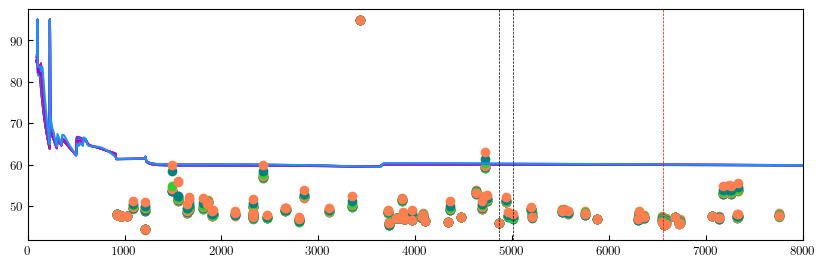

In [47]:
plt.figure(figsize=(30/3, 3))
for i in range(model.nebem_age.size):
    
    plt.plot(model.csp_lambda, -model.nebem_cont[:, i, 0, 0], label='Continuum')
    plt.plot(model.nebem_line_pos, -model.nebem_line[:, i, 0, 0], 'o', label='Lines')
plt.xlim(0, 8000)

plt.axvline(5007, color='k', ls='--', lw=0.5)
plt.axvline(6562, color='r', ls='--', lw=0.5)
plt.axvline(4861, color='k', ls='--', lw=0.5)

Text(0, 0.5, 'Flux')

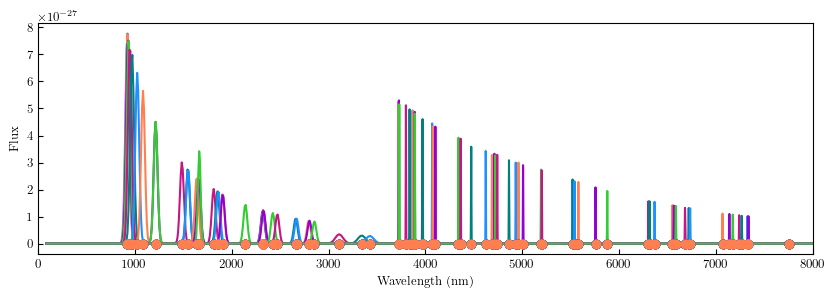

In [50]:
plt.figure(figsize=(30/3, 3))
plt.plot(model.csp_lambda, model.gaussnebarr)
plt.xlim(0, 8000)
for i in range(model.nebem_age.size):
    plt.plot(model.nebem_line_pos, 10**(model.nebem_line[:, i, 0, 0]), 'o', label='Lines')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux')

In [57]:
spec = model.evaluate(logZ=-1.0, logU=-2.5, logage=jnp.log10(1e7), Q=1e32)

/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_94599/217154202.py:131: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  logQ = jnp.log(jnp.asarray(Q, dtype=jnp.float64)) / jnp.log(10.)


In [58]:
spec

Array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 3.6720050e-28,
       3.6760066e-28, 3.6800125e-28], dtype=float32)

(300.0, 6100.0)

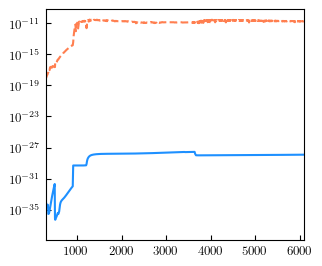

In [62]:
plt.figure(figsize=(10/3, 3))
plt.plot(model.csp_lambda, spec, label='Nebular Spectrum', lw=1.5)
plt.plot(spectrum['wave'], spectrum['flux'], label='SSP Spectrum', lw=1.5, ls='--')
plt.yscale('log')
plt.xlim(300, 6100)
